# Detección de personas y vehículos desde drones
### Trabajo práctico 4 · Visión artificial
**VisDrone2019-DET · YOLO · Transfer learning**

## Resumen
Se estudia la adaptación de un detector de objetos a imágenes aéreas mediante aprendizaje por transferencia. Se utiliza VisDrone2019-DET, con diez categorías y particiones oficiales, y una variante compacta de YOLO inicializada con pesos preentrenados. La arquitectura y sus parámetros se identifican en el protocolo de cada evaluación. Se consideran precisión, exhaustividad, calidad de localización y coste de inferencia.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.environ.get('TP4_ROOT', Path.cwd())).resolve()
if not (ROOT / 'config.yaml').exists() and (ROOT.parent / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from tp4 import notebook_view as view

RUN_ID = None
ctx = view.context(ROOT, RUN_ID, final_only=True)

## 1. Introducción
La percepción visual desde drones combina cambios de escala, perspectiva elevada, oclusión y alta densidad de objetos. Una persona o un vehículo puede ocupar pocos píxeles, lo que dificulta tanto su clasificación como la ubicación precisa de su contorno.

La detección devuelve una categoría, una caja y una confianza por objeto. En robótica, esta información puede alimentar seguimiento, conteo y análisis de escenas. El alcance de este trabajo es la detección en imágenes estáticas.

**Pregunta de investigación:** ¿qué capacidad de detección presenta un modelo compacto de YOLO al adaptarse a las categorías de VisDrone y qué limitaciones revelan sus errores?

## 2. Objetivos y fundamento del modelo
El objetivo es adaptar un detector pequeño a imágenes aéreas y caracterizar su desempeño mediante métricas globales, resultados por clase y análisis visual.

YOLO predice cajas y categorías en una pasada. Las variantes nano de YOLO11 y YOLO26 permiten estudiar detectores de tamaño y coste computacional reducidos [3]. El aprendizaje por transferencia reutiliza representaciones aprendidas en COCO y adapta la red a las diez categorías de VisDrone. La tabla metodológica identifica el modelo utilizado en los resultados presentados.

La hipótesis es que las representaciones preentrenadas aportan características útiles, mientras que la baja resolución de los objetos y las oclusiones limitan la detección. Su interpretación depende del presupuesto de entrenamiento y de la evidencia observada.

## 3. Datos y anotaciones
VisDrone2019-DET contiene imágenes aéreas con personas y vehículos en escenarios urbanos y rurales [1, 2]. Se conservaron sus particiones oficiales. El entrenamiento ajusta los pesos, la validación permite seleccionar el modelo y test-dev constituye una partición independiente.

La auditoría comprueba la correspondencia entre imágenes y anotaciones, las dimensiones de las cajas y los índices de clase.

In [2]:
view.dataset_table(ctx)

| Partición | Imágenes auditadas | Cajas válidas | Score 0 excluido | Uso |
|---|---|---|---|---|
| train | 6471 | 343204 | 10345 | Ajustar pesos |
| val | 548 | 38759 | 1410 | Seleccionar / diagnosticar |
| test-dev | 1610 | 75102 | 2445 | Evaluación final reservada |

**Control de calidad:** se excluyeron 1 cajas con tamaño inválido. Se conservaron las imágenes y anotaciones originales.

### Representación de las clases
| Categoría original → YOLO | Clase | Categoría original → YOLO | Clase |
|---|---|---|---|
| 1 → 0 | pedestrian | 6 → 5 | truck |
| 2 → 1 | people | 7 → 6 | tricycle |
| 3 → 2 | bicycle | 8 → 7 | awning-tricycle |
| 4 → 3 | car | 9 → 8 | bus |
| 5 → 4 | van | 10 → 9 | motor |

`pedestrian` corresponde a personas de pie o caminando; `people` incluye otras posturas [2]. Se conservaron las anotaciones con score 1 y categoría entre 1 y 10. Las regiones con score 0 se excluyeron, así como las cajas de tamaño inválido.

Para una imagen de dimensiones W×H, la caja original `(x,y,w,h)` se expresa como `((x+w/2)/W, (y+h/2)/H, w/W, h/H)`. Por ejemplo, `(100,50,200,100)` en una imagen de 1000×500 produce `(0.2,0.2,0.2,0.2)`.

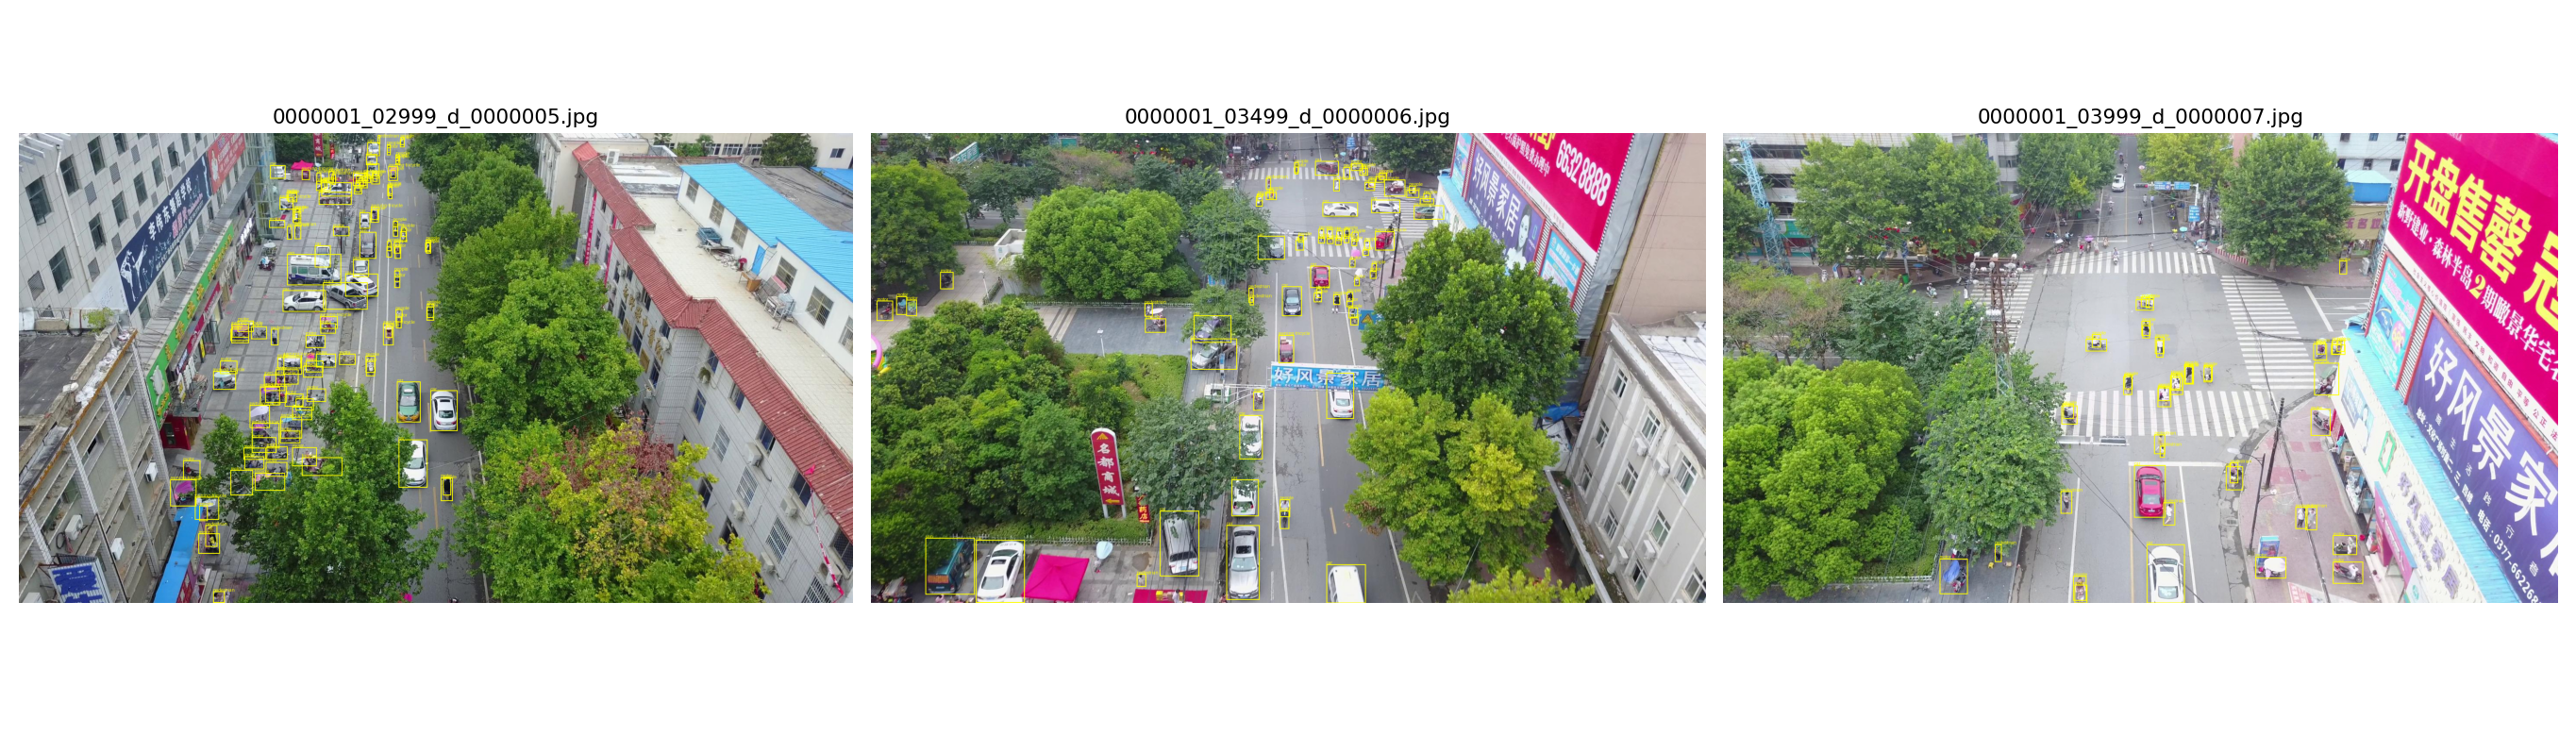

*Figura 1. Cajas convertidas sobre tres imágenes de validación. La revisión visual complementa los controles automáticos.*

In [3]:
view.figure(ctx, 'data/box_review.png', 'Figura 1. Cajas convertidas sobre tres imágenes de validación. La revisión visual complementa los controles automáticos.')

### Distribución de clases y tamaños
El número de anotaciones por clase describe el desbalance del conjunto. El cociente entre el área de cada caja y el área de la imagen caracteriza el tamaño relativo de los objetos.

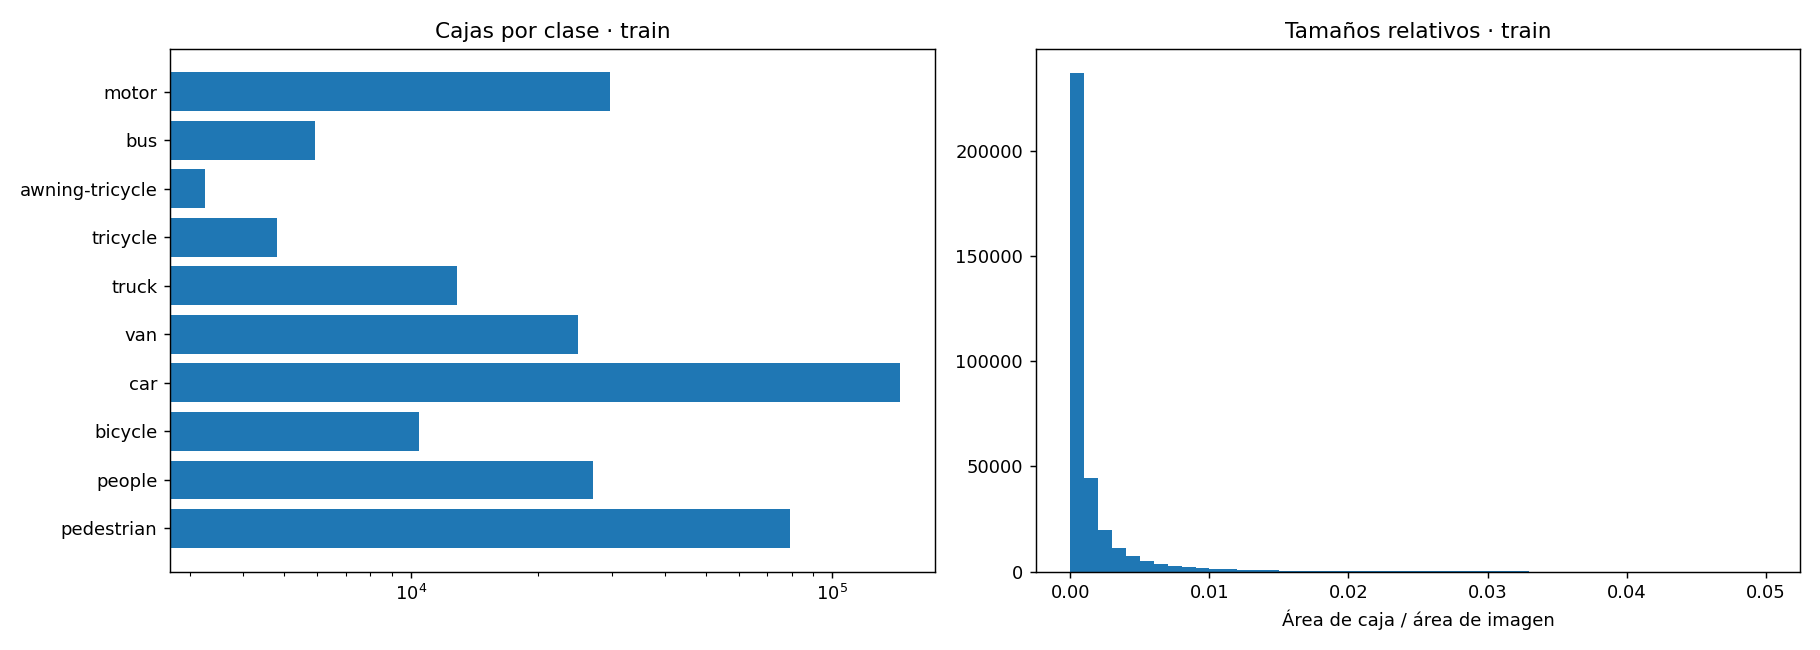

*Figura 2. Distribución de clases y áreas relativas en train. El histograma representa el intervalo indicado en su eje horizontal.*

In [4]:
view.figure(ctx, 'data/audit.png', 'Figura 2. Distribución de clases y áreas relativas en train. El histograma representa el intervalo indicado en su eje horizontal.')

## 4. Metodología experimental
Se utilizó aprendizaje por transferencia y una semilla fija. Las particiones oficiales se conservaron durante el procesamiento. La selección del checkpoint se realizó con validación; todas las cifras de una evaluación provienen del mismo modelo y protocolo.

La tabla presenta el presupuesto de entrenamiento y el entorno correspondientes a los resultados analizados.

In [5]:
view.protocol(ctx)

| Variable | Configuración experimental |
|---|---|
| Modelo / inicialización | yolo11n.pt · pesos preentrenados COCO |
| Épocas configuradas | 50 |
| Train / val | split completo / split completo imágenes |
| Resolución / batch / semilla | 640 px / 4 / 42 |
| GPU | NVIDIA GeForce RTX 5070 Laptop GPU |
| PyTorch / Ultralytics | 2.13.0+cu130 / 8.4.162 |

### Ajuste y selección del modelo
El entrenamiento actualiza los pesos con las imágenes de train. La evaluación utiliza el checkpoint seleccionado por el procedimiento de validación de Ultralytics. El núcleo de ambas operaciones se expresa a continuación.

In [6]:
def ajustar_y_evaluar(configuracion, directorio):
    from ultralytics import YOLO
    from tp4.experiment import device_or_raise
    dispositivo = device_or_raise(configuracion['device'])
    modelo = YOLO(configuracion['model'])
    modelo.train(
        data=configuracion['data_yaml'], epochs=configuracion['epochs'],
        imgsz=configuracion['imgsz'], batch=configuracion['batch'],
        workers=configuracion['workers'], seed=configuracion['seed'],
        device=dispositivo, project=str(directorio), name='train',
    )
    checkpoint = Path(directorio) / 'train' / 'weights' / 'best.pt'
    return YOLO(str(checkpoint)).val(
        data=configuracion['data_yaml'], split='val',
        imgsz=configuracion['imgsz'], batch=configuracion['batch'],
        workers=configuracion['workers'], device=dispositivo,
    )

## 5. Criterios de evaluación
Una detección correcta requiere acertar la clase y alcanzar el solapamiento exigido. La **IoU** es el cociente entre el área de intersección y el área de unión de las cajas.

| Métrica | Definición | Interpretación |
|---|---|---|
| Precision | TP / (TP + FP) | Proporción de predicciones correctas |
| Recall | TP / (TP + FN) | Proporción de objetos encontrados |
| mAP@0.5 | Media entre clases del área bajo la curva precision–recall, con IoU 0,5 | Calidad de detección con localización moderada |
| mAP@0.5:0.95 | Media entre clases y diez umbrales de IoU de 0,50 a 0,95 | Exigencia mayor sobre la localización |

Se emplea el evaluador estándar de Ultralytics. Excluir etiquetas de regiones ignoradas no reproduce necesariamente el tratamiento del evaluador oficial de VisDrone; las cifras no se presentan como resultados oficiales de ese benchmark.

## 6. Resultados de validación
Las métricas se expresan como porcentajes y se interpretan bajo el protocolo descrito. Precision y recall resumen el punto de operación del evaluador, mientras que AP integra distintos umbrales de confianza.

In [7]:
view.metrics(ctx)

### Resultados por clase
El desglose permite identificar diferencias entre categorías. Estas diferencias se consideran junto con su frecuencia en el conjunto y los ejemplos de detección.

In [8]:
view.metrics(ctx, per_class=True)

### Evolución del ajuste y matriz de confusión
Las curvas describen la evolución de pérdidas y métricas a lo largo del entrenamiento. La matriz resume asociaciones entre clases y errores con el fondo para la validación del modelo.

In [9]:
view.figure(ctx, 'train/results.png', 'Figura 3. Pérdidas de entrenamiento y evolución de las métricas de validación.', run=True)

In [10]:
view.figure(ctx, 'validation/confusion_matrix.png', 'Figura 4. Matriz de confusión del evaluador Ultralytics sobre validación.', run=True)

## 7. Análisis de errores
El análisis de ejemplos de validación utiliza confianza 0,25 y asociación uno a uno por clase e IoU 0,5. Los conteos corresponden a una muestra de imágenes y no equivalen al mAP, que integra un barrido de confianza.

In [11]:
view.errors(ctx)

In [12]:
view.figure(ctx, 'error_gallery.jpg', 'Figura 5. Dos ejemplos de la muestra analizada: rojo indica falsos negativos y cian, falsos positivos.', run=True, first_row=True)

### Comparación visual con las anotaciones
La comparación del mismo lote muestra diferencias de ubicación, categoría y cobertura entre las anotaciones y las predicciones.

In [13]:
view.figure(ctx, 'validation/val_batch0_labels.jpg', 'Figura 6. Anotaciones de referencia del primer lote de validación.', run=True)

In [14]:
view.figure(ctx, 'validation/val_batch0_pred.jpg', 'Figura 7. Predicciones correspondientes al mismo lote de validación.', run=True)

## 8. Coste de inferencia
La latencia corresponde a una llamada completa de predicción, con batch 1, calentamiento y sincronización CUDA. La medición caracteriza el entorno local utilizado.

In [15]:
view.latency(ctx)

## 9. Discusión y conclusiones

In [16]:
view.conclusion(ctx)

### Alcance de las conclusiones
La evaluación corresponde a imágenes estáticas y una única semilla de entrenamiento. No se estimó variabilidad entre entrenamientos ni desempeño específico por tamaño u oclusión. Los ejemplos visuales permiten describir errores, pero no atribuir causalmente su origen.

La latencia sobre una imagen repetida no representa la variabilidad entre escenas ni el rendimiento de hardware embarcado. Estas condiciones delimitan la interpretación de las métricas para aplicaciones robóticas.

## 10. Referencias
1. Zhu et al. *Detection and Tracking Meet Drones Challenge*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 44(11), 7380–7399, 2022. [Repositorio y dataset](https://github.com/VisDrone/VisDrone-Dataset).
2. Ultralytics. [VisDrone: categorías, particiones y formato de anotaciones](https://docs.ultralytics.com/datasets/detect/visdrone/).
3. Ultralytics. [YOLO11](https://docs.ultralytics.com/models/yolo11/), [YOLO26](https://docs.ultralytics.com/models/yolo26/) y [entrenamiento](https://docs.ultralytics.com/modes/train/).

El dataset pertenece al equipo AISKYEYE de la Universidad de Tianjin. Su utilización en este trabajo tiene carácter académico [condiciones de los autores](https://aiskyeye.com/data-protection/).